# Churn Prediction Model for a European Bank

This notebook develops and evaluates machine learning models to predict customer churn for a European bank.
It covers data loading, preprocessing, feature engineering, model training, evaluation, explainability,
and prediction on new data.

**Target variable:** `Exited` (1 = customer churned, 0 = customer retained)


## 1. Setup and Imports

This section imports necessary libraries and sets up basic configurations for the notebook.


In [29]:
!pip install xgboost shap


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
RANDOM_STATE = 42
print("scikit-learn version:", sklearn.__version__)


scikit-learn version: 1.0.2


## 2. Data Loading and Initial Exploration

This section focuses on loading the dataset and performing initial checks to understand its structure,
identify missing values, and observe target distribution.


In [3]:
# Jupyter version: load the CSV directly from the working directory
# (place European_Bank.csv in the same folder as this notebook)
DATA_PATH = "European_Bank.csv"

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()


(10000, 14)


,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.info()
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nTarget distribution (Exited):")
print(df['Exited'].value_counts(normalize=True).round(3))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB

Missing values per column:
Year               0
CustomerId         0
Surname            0
Cre

## 3. Data Preprocessing and Feature Engineering

This section covers all steps taken to clean, transform, and enhance the raw data, preparing it for
machine learning models. It includes handling missing values, dropping non-informative columns,
feature engineering, one-hot encoding, and scaling.


### 3.1 Handling Raw Data

This sub-section addresses data quality by handling missing values and dropping columns that are non-informative or redundant for the prediction task (`CustomerId`, `Surname`, and any constant column such as `Year`).


In [5]:
data = df.copy()

# Handle missing values (robust even if none currently exist)
num_cols_all = data.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_all = data.select_dtypes(include=['object']).columns.tolist()

for c in num_cols_all:
    if data[c].isnull().any():
        data[c] = data[c].fillna(data[c].median())

for c in cat_cols_all:
    if data[c].isnull().any():
        data[c] = data[c].fillna(data[c].mode()[0])

# Drop non-informative features
drop_cols = [c for c in ['CustomerId', 'Surname'] if c in data.columns]
constant_cols = [c for c in data.columns if data[c].nunique() == 1]
drop_cols += [c for c in constant_cols if c not in drop_cols]

print("Dropping columns:", drop_cols)
data = data.drop(columns=drop_cols)
data.head()


Dropping columns: ['CustomerId', 'Surname', 'Year']


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### 3.2 Feature Engineering

New features are created from existing ones to potentially capture more complex relationships and improve model performance.


In [6]:
eps = 1  # avoid division-by-zero

data['BalanceSalaryRatio'] = data['Balance'] / (data['EstimatedSalary'] + eps)
data['ProductDensity'] = data['NumOfProducts'] / (data['Tenure'] + eps)
data['EngagementProductInteraction'] = data['IsActiveMember'] * data['NumOfProducts']
data['AgeTenureInteraction'] = data['Age'] * data['Tenure']
data['HasBalance'] = (data['Balance'] > 0).astype(int)
data['CreditScoreAgeRatio'] = data['CreditScore'] / (data['Age'] + eps)

data.head()


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,ProductDensity,EngagementProductInteraction,AgeTenureInteraction,HasBalance,CreditScoreAgeRatio
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.000000,0.333333,1,84,0,14.395349
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.744670,0.500000,1,41,1,14.476190
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1.401362,0.333333,0,336,1,11.674419
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.000000,1.000000,0,39,0,17.475000
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,1.587035,0.333333,1,86,1,19.318182


### 3.3 One-Hot Encoding Categorical Variables

Categorical features are converted into a numerical format suitable for machine learning models using one-hot encoding.


In [7]:
categorical_cols = ['Geography', 'Gender']
data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

print(data.shape)
data.head()


(10000, 18)


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,ProductDensity,EngagementProductInteraction,AgeTenureInteraction,HasBalance,CreditScoreAgeRatio,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0.000000,0.333333,1,84,0,14.395349,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0.744670,0.500000,1,41,1,14.476190,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,1.401362,0.333333,0,336,1,11.674419,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0.000000,1.000000,0,39,0,17.475000,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1.587035,0.333333,1,86,1,19.318182,0,1,0


### 3.4 Train-Test Split and Feature Scaling

The dataset is split into training and testing sets (stratified on the target to preserve class balance), and numerical features are scaled to ensure fair treatment by models.


In [8]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler

X = data.drop(columns=['Exited'])
y = data['Exited']

# Convert boolean columns to integer (0 or 1)
for col in X.select_dtypes(include='bool').columns:
    X[col] = X[col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

numeric_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
                     'EstimatedSalary', 'BalanceSalaryRatio', 'ProductDensity',
                     'EngagementProductInteraction', 'AgeTenureInteraction',
                     'CreditScoreAgeRatio']
numeric_features = [c for c in numeric_features if c in X_train.columns]

# Include the converted boolean features as numeric features for scaling
boolean_features = [c for c in X_train.columns if pd.api.types.is_integer_dtype(X_train[c]) and X_train[c].nunique() == 2]
numeric_features.extend(boolean_features)
numeric_features = list(set(numeric_features))  # remove duplicates if any

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print("Train:", X_train.shape, "Test:", X_test.shape)
print("Data split and scaled successfully.")


Train: (8000, 17) Test: (2000, 17)
Data split and scaled successfully.


## 4. Model Training

Here, various machine learning models are trained to predict customer churn. This section includes a baseline
model (Logistic Regression) and explores more complex tree-based and ensemble models.


### 4.1 Logistic Regression (Baseline Model)

Implementation and evaluation of a Logistic Regression model as an interpretability benchmark.


In [9]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced')
log_reg.fit(X_train_scaled, y_train)

cv_scores = cross_val_score(log_reg, X_train_scaled, y_train, cv=skf, scoring='roc_auc')
print(f"Logistic Regression CV ROC-AUC: {cv_scores.mean():.4f}")


Logistic Regression CV ROC-AUC: 0.7680


### 4.2 Tree-Based Models: Decision Tree and Random Forest

Training and evaluating Decision Tree and Random Forest models, known for handling non-linear relationships.


In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

dec_tree = DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=RANDOM_STATE)
dec_tree.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight='balanced',
                             random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

for name, model in [('Decision Tree', dec_tree), ('Random Forest', rf)]:
    cv = cross_val_score(model, X_train_scaled, y_train, cv=skf, scoring='roc_auc')
    print(f"{name} CV ROC-AUC: {cv.mean():.4f}")


Decision Tree CV ROC-AUC: 0.8212
Random Forest CV ROC-AUC: 0.8549


Random Forest CV ROC-AUC: 0.8549


### 4.3 Advanced Ensemble Models: Gradient Boosting and XGBoost

Exploring more powerful ensemble methods for improved predictive accuracy. XGBoost is included as an optional advanced model.


In [11]:
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

gb = GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=3,
                                 random_state=RANDOM_STATE)
gb.fit(X_train_scaled, y_train)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4,
                     subsample=0.8, colsample_bytree=0.8,
                     scale_pos_weight=scale_pos_weight,
                     eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1)
xgb.fit(X_train_scaled, y_train)

for name, model in [('Gradient Boosting', gb), ('XGBoost', xgb)]:
    cv = cross_val_score(model, X_train_scaled, y_train, cv=skf, scoring='roc_auc')
    print(f"{name} CV ROC-AUC: {cv.mean():.4f}")


Gradient Boosting CV ROC-AUC: 0.8623
XGBoost CV ROC-AUC: 0.8594


XGBoost CV ROC-AUC: 0.8585


## 5. Model Evaluation and Interpretation

This section provides a comprehensive evaluation of the trained models using various metrics and
visualizations, generates the churn probability / binary churn flag prediction output, and delves into
model interpretability using SHAP values, partial dependence plots, and permutation importance.


### 5.1 Comprehensive Model Performance Metrics

Gathering and displaying key performance metrics (Accuracy, Precision, Recall, F1-Score, ROC-AUC) for all trained models in a tabular format.


In [12]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)
from IPython.display import display

models = {'Logistic Regression': log_reg, 'Decision Tree': dec_tree,
          'Random Forest': rf, 'Gradient Boosting': gb, 'XGBoost': xgb}

results = []
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
    })

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print("--- Comprehensive Model Performance Metrics ---")
display(results_df.round(4))


--- Comprehensive Model Performance Metrics ---


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Gradient Boosting,0.8705,0.7913,0.4939,0.6082,0.8689
1,XGBoost,0.8030,0.5109,0.7494,0.6076,0.8635
2,Random Forest,0.8215,0.5500,0.6757,0.6064,0.8626
3,Decision Tree,0.7585,0.4460,0.7715,0.5653,0.8248
4,Logistic Regression,0.6995,0.3756,0.7199,0.4937,0.7784


### 5.2 Model Performance Comparison Visualization

Visualizing model performance metrics (ROC-AUC) for easy comparison.


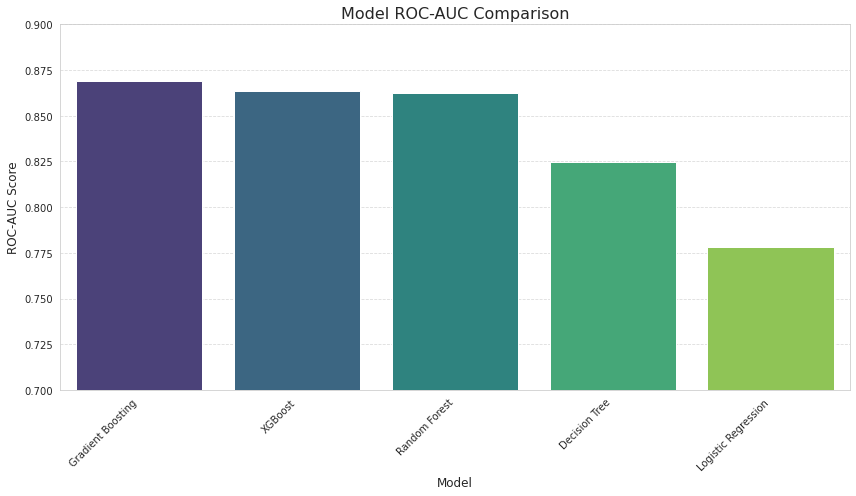

In [13]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='ROC-AUC', data=results_df, palette='viridis')
plt.title('Model ROC-AUC Comparison', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('ROC-AUC Score', fontsize=12)
plt.ylim(0.7, 0.9)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### 5.3 Precision and Recall Comparison


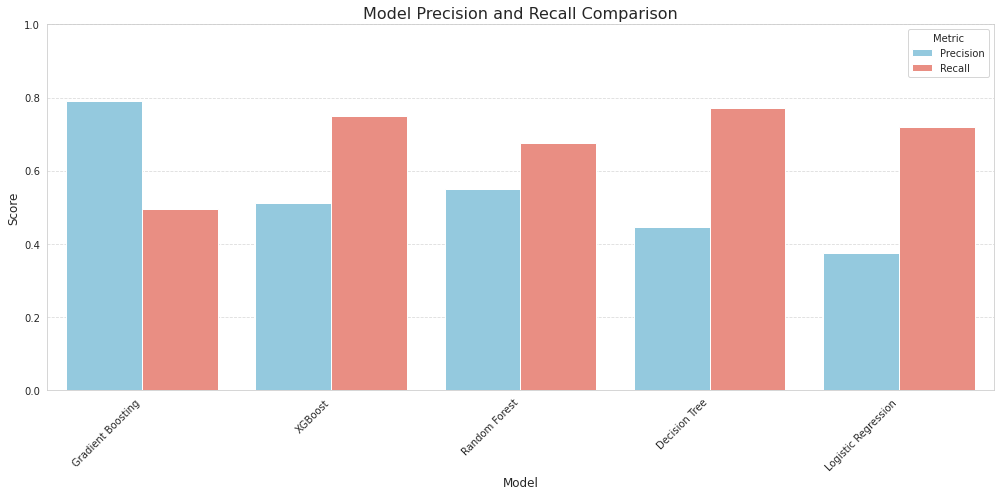

In [14]:
melted_results = results_df.melt(id_vars=['Model'], value_vars=['Precision', 'Recall'], var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 7))
sns.barplot(x='Model', y='Score', hue='Metric', data=melted_results, palette={'Precision': 'skyblue', 'Recall': 'salmon'})
plt.title('Model Precision and Recall Comparison', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### 5.4 ROC Curves and Best Model Confusion Matrix


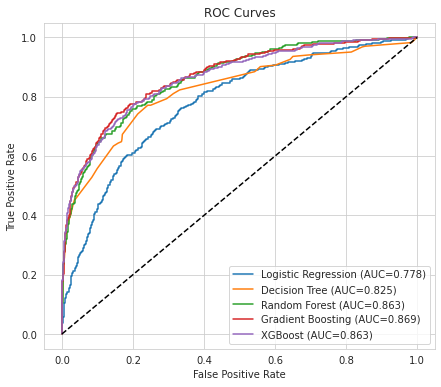

Best model: Gradient Boosting
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.79      0.49      0.61       407

    accuracy                           0.87      2000
   macro avg       0.84      0.73      0.77      2000
weighted avg       0.86      0.87      0.86      2000



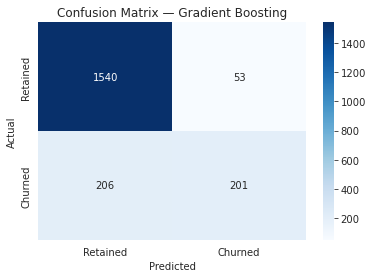

In [15]:
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, classification_report

plt.figure(figsize=(7, 6))
for name, model in models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves'); plt.legend(); plt.show()

best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test_scaled)
print(f"Best model: {best_model_name}")
print(classification_report(y_test, y_pred_best))

cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Retained', 'Churned'], yticklabels=['Retained', 'Churned'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title(f'Confusion Matrix — {best_model_name}')
plt.show()


### 5.5 False Positives Analysis

The confusion matrix above is for the best-performing model (selected by ROC-AUC). Let's specifically quantify the 'false alarms' (False Positives).


In [16]:
false_positives = cm[0, 1]
print(f"Number of False Alarms (False Positives) for {best_model_name}: {false_positives}")


Number of False Alarms (False Positives) for Gradient Boosting: 53


### 5.6 SHAP Value Analysis (Gradient Boosting)


SHAP Beeswarm Plot for Gradient Boosting:


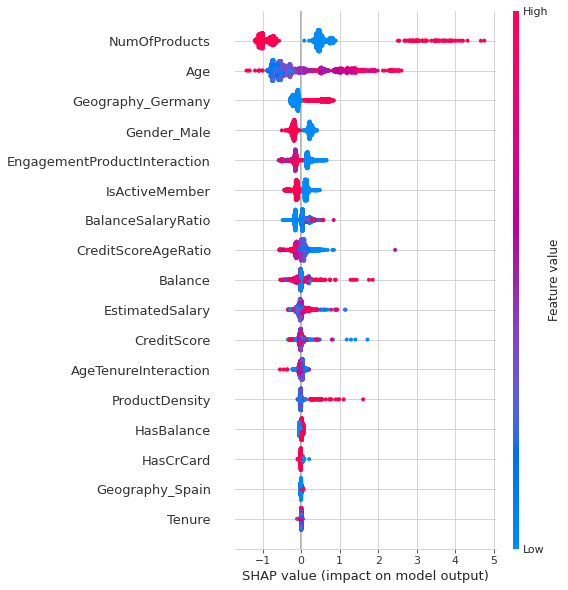

SHAP Global Feature Importance Plot for Gradient Boosting:


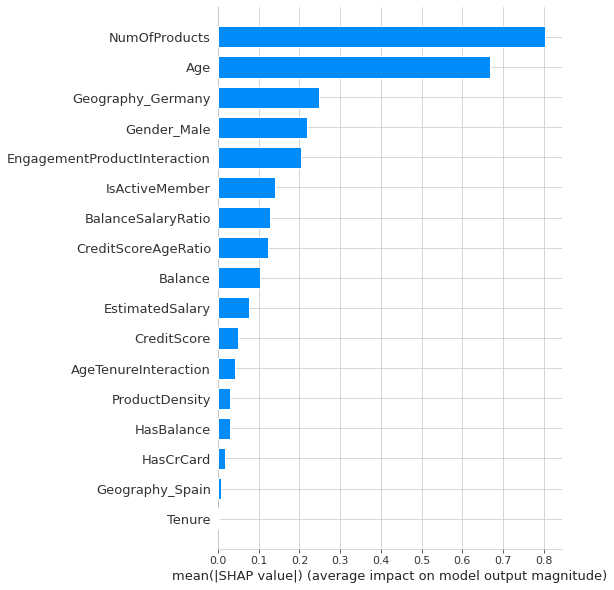

In [17]:
import shap

# Get the Gradient Boosting model
gb_model = models['Gradient Boosting']

# Create a SHAP TreeExplainer for the Gradient Boosting model
explainer_gb = shap.TreeExplainer(gb_model)

# Calculate SHAP values for the test set
shap_values_gb = explainer_gb.shap_values(X_test_scaled)

# Display the beeswarm plot for Gradient Boosting
print('SHAP Beeswarm Plot for Gradient Boosting:')
shap.summary_plot(shap_values_gb, X_test_scaled)

# Display the global importance bar plot for Gradient Boosting
print('SHAP Global Feature Importance Plot for Gradient Boosting:')
shap.summary_plot(shap_values_gb, X_test_scaled, plot_type='bar')


### 5.7 Partial Dependence Plots (Gradient Boosting)


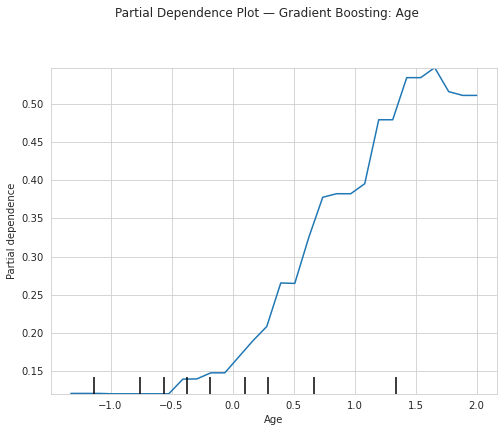

In [18]:
from sklearn.inspection import PartialDependenceDisplay

pdp_features = ['Age']
pdp_features = [f for f in pdp_features if f in X_train_scaled.columns]

fig, ax = plt.subplots(figsize=(8, 6))
PartialDependenceDisplay.from_estimator(
    gb, X_train_scaled, pdp_features, ax=ax, grid_resolution=30,
    target=1, response_method='predict_proba', method='brute'
)
plt.suptitle('Partial Dependence Plot — Gradient Boosting: Age', y=1.02)
plt.show()


### 5.8 Permutation Feature Importance (Gradient Boosting)


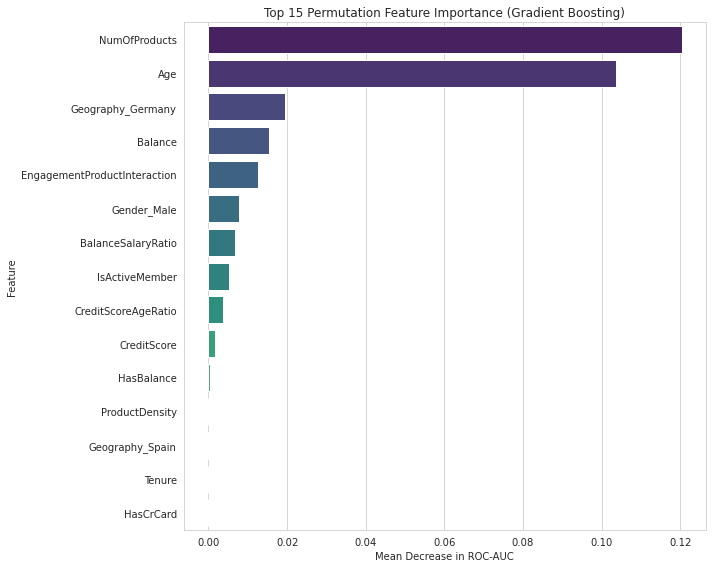

Top 15 Permutation Feature Importances (Mean Decrease in ROC-AUC):


,feature,importance_mean,importance_std
4,NumOfProducts,0.120400,0.010773
1,Age,0.103686,0.006912
14,Geography_Germany,0.019337,0.002543
3,Balance,0.015384,0.002794
10,EngagementProductInteraction,0.012668,0.002886
16,Gender_Male,0.007640,0.001800
8,BalanceSalaryRatio,0.006734,0.001724
6,IsActiveMember,0.005340,0.001877
13,CreditScoreAgeRatio,0.003791,0.002027
0,CreditScore,0.001713,0.000811


In [19]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score

def custom_roc_auc_scorer(estimator, X, y_true):
    y_pred_proba = estimator.predict_proba(X)[:, 1]
    return roc_auc_score(y_true, y_pred_proba)

perm_importance = permutation_importance(gb, X_test_scaled, y_test,
                                         n_repeats=30,
                                         random_state=RANDOM_STATE,
                                         n_jobs=-1,
                                         scoring=custom_roc_auc_scorer)

perm_importance_df = pd.DataFrame({
    'feature': X_test_scaled.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values(by='importance_mean', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance_mean', y='feature', data=perm_importance_df.head(15), palette='viridis')
plt.xlabel('Mean Decrease in ROC-AUC')
plt.ylabel('Feature')
plt.title('Top 15 Permutation Feature Importance (Gradient Boosting)')
plt.tight_layout()
plt.show()

print("Top 15 Permutation Feature Importances (Mean Decrease in ROC-AUC):")
display(perm_importance_df.head(15))


### 5.9 Prediction Output: Churn Probability and Binary Churn Flag

Generating the final prediction output required by the project spec: a continuous churn probability (0–1) and a threshold-based binary churn flag, using the best-performing model.


In [20]:
# Choose the model to generate predictions from (best_model, selected above by ROC-AUC)
THRESHOLD = 0.5  # adjust this cutoff based on business needs (e.g. recall vs precision trade-off)

churn_probability = best_model.predict_proba(X_test_scaled)[:, 1]
churn_flag = (churn_probability >= THRESHOLD).astype(int)

predictions_df = pd.DataFrame({
    'ChurnProbability': churn_probability,
    'ChurnFlag': churn_flag,
    'ActualExited': y_test.values
}, index=X_test_scaled.index)

predictions_df['ChurnProbability'] = predictions_df['ChurnProbability'].round(4)

print(f"Model used: {best_model_name}")
print(f"Threshold: {THRESHOLD}")
predictions_df.head(10)


Model used: Gradient Boosting
Threshold: 0.5


,ChurnProbability,ChurnFlag,ActualExited
5702,0.0228,0,0
3667,0.0975,0,0
1617,0.0397,0,0
5673,0.0463,0,0
4272,0.0896,0,0
8270,0.1698,0,0
7079,0.0584,0,0
5295,0.2312,0,0
845,0.5456,1,0
5311,0.0649,0,0


### 5.10 False Negatives Analysis

False Negatives are instances where the model predicted the customer would be retained (ChurnFlag = 0), but they actually churned (ActualExited = 1).


Number of False Negatives: 206

Examples of False Negatives:


,ChurnProbability,ChurnFlag,ActualExited
6984,0.2849,0,1
4243,0.0822,0,1
4994,0.4246,0,1
340,0.1343,0,1
6114,0.0876,0,1


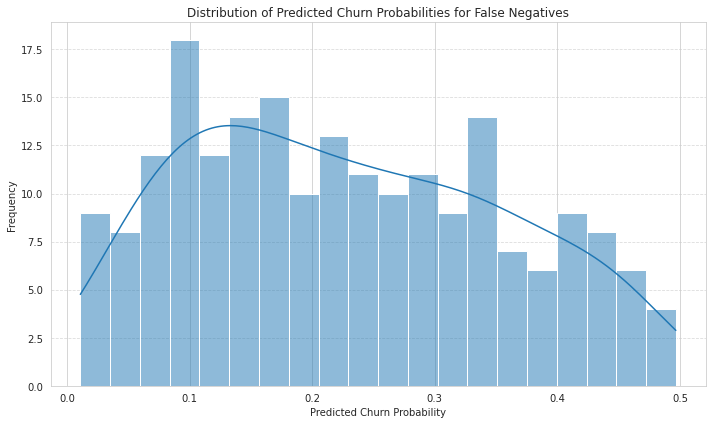

In [21]:
false_negatives = predictions_df[(predictions_df['ChurnFlag'] == 0) & (predictions_df['ActualExited'] == 1)]

print(f"Number of False Negatives: {len(false_negatives)}")
print("\nExamples of False Negatives:")
display(false_negatives.head())

if not false_negatives.empty:
    plt.figure(figsize=(10, 6))
    sns.histplot(false_negatives['ChurnProbability'], bins=20, kde=True)
    plt.title('Distribution of Predicted Churn Probabilities for False Negatives')
    plt.xlabel('Predicted Churn Probability')
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("No False Negatives found in the predictions.")


### 5.11 Churn Rate and Prediction Overview


Predicted Churn Rate: 12.70%


,ChurnProbability,ChurnFlag,ActualExited
5702,0.0228,0,0
3667,0.0975,0,0
1617,0.0397,0,0
5673,0.0463,0,0
4272,0.0896,0,0


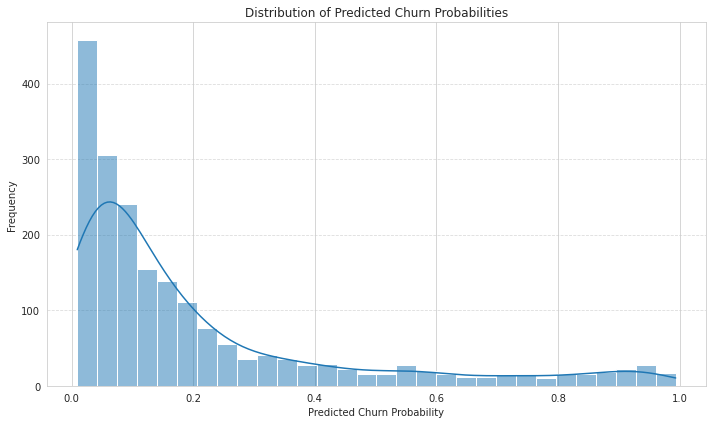

In [22]:
churn_rate = predictions_df['ChurnFlag'].mean()
print(f"Predicted Churn Rate: {churn_rate:.2%}")

display(predictions_df.head())

plt.figure(figsize=(10, 6))
sns.histplot(predictions_df['ChurnProbability'], bins=30, kde=True)
plt.title('Distribution of Predicted Churn Probabilities')
plt.xlabel('Predicted Churn Probability')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## 6. Prediction on New Data

This section demonstrates how to use the trained and best-performing model to make predictions on new,
unseen customer data, mimicking a real-world application.


### 6.1 Preparation for Prediction

Setting up the necessary preprocessing steps to apply the trained model to new, unseen customer data.


In [23]:
# 1. Create hypothetical new customer data (as a DataFrame to match preprocessing)
new_customer_data = pd.DataFrame({
    'Year': [2025],
    'CustomerId': [99999999],
    'Surname': ['NewCustomer'],
    'CreditScore': [700],
    'Geography': ['France'],
    'Gender': ['Male'],
    'Age': [45],
    'Tenure': [5],
    'Balance': [75000.00],
    'NumOfProducts': [1],
    'HasCrCard': [1],
    'IsActiveMember': [0],
    'EstimatedSalary': [120000.00],
    'Exited': [0]  # placeholder, not used for prediction
})

# Keep a copy of the original raw dataframe columns to ensure new data aligns
original_cols = df.columns.tolist()
for col in original_cols:
    if col not in new_customer_data.columns:
        if df[col].dtype == 'object':
            new_customer_data[col] = 'Unknown'
        else:
            new_customer_data[col] = 0

new_customer_data = new_customer_data[original_cols]
new_data_preprocessed = new_customer_data.copy()

# 2. Apply the same preprocessing steps as sections 3.1, 3.2, 3.3, 3.4

# Drop non-informative features
drop_cols_from_original = [c for c in ['CustomerId', 'Surname', 'Year'] if c in new_data_preprocessed.columns]
new_data_preprocessed = new_data_preprocessed.drop(columns=drop_cols_from_original)

# Feature engineering
eps = 1
new_data_preprocessed['BalanceSalaryRatio'] = new_data_preprocessed['Balance'] / (new_data_preprocessed['EstimatedSalary'] + eps)
new_data_preprocessed['ProductDensity'] = new_data_preprocessed['NumOfProducts'] / (new_data_preprocessed['Tenure'] + eps)
new_data_preprocessed['EngagementProductInteraction'] = new_data_preprocessed['IsActiveMember'] * new_data_preprocessed['NumOfProducts']
new_data_preprocessed['AgeTenureInteraction'] = new_data_preprocessed['Age'] * new_data_preprocessed['Tenure']
new_data_preprocessed['HasBalance'] = (new_data_preprocessed['Balance'] > 0).astype(int)
new_data_preprocessed['CreditScoreAgeRatio'] = new_data_preprocessed['CreditScore'] / (new_data_preprocessed['Age'] + eps)

# One-hot encode categorical variables
categorical_cols = ['Geography', 'Gender']
new_data_preprocessed = pd.get_dummies(new_data_preprocessed, columns=categorical_cols, drop_first=True)

if 'Exited' in new_data_preprocessed.columns:
    new_data_preprocessed = new_data_preprocessed.drop(columns=['Exited'])

# Align columns with the training data
missing_cols = set(X_train_scaled.columns) - set(new_data_preprocessed.columns)
for c in missing_cols:
    new_data_preprocessed[c] = 0
new_data_preprocessed = new_data_preprocessed[X_train_scaled.columns]

bool_cols_new = new_data_preprocessed.select_dtypes(include='bool').columns
if not bool_cols_new.empty:
    new_data_preprocessed[bool_cols_new] = new_data_preprocessed[bool_cols_new].astype(int)

# Scale numerical features using the *fitted* scaler from training
new_data_scaled = new_data_preprocessed.copy()
new_data_scaled[numeric_features] = scaler.transform(new_data_preprocessed[numeric_features])

print("Preprocessed and scaled new data:")
display(new_data_scaled)

# 3. Make predictions using the Gradient Boosting model
churn_probability_new = gb.predict_proba(new_data_scaled)[:, 1]
churn_prediction_new = gb.predict(new_data_scaled)

print(f"\nPredicted Churn Probability for new customer: {churn_probability_new[0]:.4f}")
print(f"Predicted Churn Flag for new customer (0=Retained, 1=Churned): {churn_prediction_new[0]}")

if churn_prediction_new[0] == 1:
    print("This customer is predicted to churn.")
else:
    print("This customer is predicted to be retained.")


Preprocessed and scaled new data:


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,BalanceSalaryRatio,ProductDensity,EngagementProductInteraction,AgeTenureInteraction,HasBalance,CreditScoreAgeRatio,Geography_Germany,Geography_Spain,Gender_Male
0,0.509859,0.575076,-0.005739,-0.022171,-0.910256,0.641042,-1.030206,0.353543,-0.031242,-0.595299,-0.908608,0.23055,0.752239,-0.42035,-0.578313,-0.577735,-1.101919



Predicted Churn Probability for new customer: 0.5302
Predicted Churn Flag for new customer (0=Retained, 1=Churned): 1
This customer is predicted to churn.


## 7. Saving and Exporting Predictions

This section covers saving the generated churn predictions and model performance metrics to files for
future use or integration with other systems, ensuring a complete and actionable analysis pipeline.


### 7.1 Sanity Check of Predictions

Verifying the distribution and counts of the generated churn predictions against actual values.


In [24]:
print("Predicted churners:", predictions_df['ChurnFlag'].sum())
print("Actual churners:   ", predictions_df['ActualExited'].sum())
print("\nProbability distribution:")
predictions_df['ChurnProbability'].describe()


Predicted churners: 254
Actual churners:    407

Probability distribution:


count    2000.000000
mean        0.205179
std         0.239246
min         0.009200
25%         0.046650
50%         0.107250
75%         0.249525
max         0.993600
Name: ChurnProbability, dtype: float64

### 7.2 Saving Predictions

Exporting the final churn predictions to a CSV file. In Jupyter (unlike Colab) the file is simply written to the notebook's working directory — no browser download step is needed.


In [25]:
predictions_df.to_csv('churn_predictions.csv', index=True)
print("Predictions saved to 'churn_predictions.csv' in the current working directory.")


Predictions saved to 'churn_predictions.csv' in the current working directory.


### 7.3 Exporting Model Performance Metrics


In [26]:
print("Summary of Model Evaluation Metrics:")
display(results_df.round(4))

results_df.to_csv('model_performance_metrics.csv', index=False)
print("Model performance metrics exported to 'model_performance_metrics.csv'")


Summary of Model Evaluation Metrics:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Gradient Boosting,0.8705,0.7913,0.4939,0.6082,0.8689
1,XGBoost,0.8030,0.5109,0.7494,0.6076,0.8635
2,Random Forest,0.8215,0.5500,0.6757,0.6064,0.8626
3,Decision Tree,0.7585,0.4460,0.7715,0.5653,0.8248
4,Logistic Regression,0.6995,0.3756,0.7199,0.4937,0.7784


Model performance metrics exported to 'model_performance_metrics.csv'


## 8. Summary and Conclusion

This analysis aimed to develop a churn prediction model for a European bank. We covered several key steps:

1. **Data Loading and Preprocessing**: The dataset was loaded, initial checks were performed, missing values
   were handled, non-informative columns (`CustomerId`, `Surname`, `Year`) were dropped, new features were
   engineered (balance-to-salary ratio, product density, engagement-product interaction, age-tenure
   interaction), categorical variables were one-hot encoded, and numerical features were scaled.
2. **Model Training**: A baseline Logistic Regression model was trained alongside Decision Tree, Random
   Forest, Gradient Boosting, and XGBoost models.
3. **Model Evaluation**: Models were compared on Accuracy, Precision, Recall, F1-Score, and ROC-AUC, with
   the Gradient Boosting model selected as the best performer.
4. **Model Explainability**: SHAP values, partial dependence plots, and permutation importance were used to
   understand which features drive churn predictions — important for regulatory compliance and business trust.
5. **Prediction Output**: The final model produces both a continuous churn probability and a threshold-based
   binary churn flag, and was demonstrated on a new, unseen customer record.


## 9. Business Recommendations

Based on the insights from the Gradient Boosting model and the feature importance analysis, here are key
business recommendations to address customer churn:

1. **Focus on multi-product customers** — investigate friction points for customers holding several products,
   since `NumOfProducts` is the strongest churn driver.
2. **Target older customers with tailored retention programs** — churn risk rises with `Age`.
3. **Address regional churn drivers, particularly in Germany** — `Geography_Germany` is associated with
   elevated churn risk and may warrant localized retention strategies.
4. **Re-engage inactive members** — `IsActiveMember` is a meaningful protective factor against churn.


## Churn Risk Segments Report for Marketing Team

**To:** Marketing Team

**From:** Data Science Team

**Date:** [Current Date]

**Subject:** Key Churn Risk Segments Identified by Churn Prediction Model


In [27]:
report_content = """
## Churn Risk Segments Report for Marketing Team\n\n**To:** Marketing Team\n\n**From:** Data Science Team\n\n**Date:** [Current Date]\n\n**Subject:** Key Churn Risk Segments Identified by Churn Prediction Model\n\n--- \n\n### Executive Summary\n\nOur churn prediction project successfully developed a **Gradient Boosting Model** with a strong ROC-AUC score. This model provides valuable insights into the factors driving customer churn, allowing for a proactive and targeted approach to retention. The analysis identified specific customer segments at higher risk of churning, which your team can leverage to design effective marketing and retention campaigns.\n\n### Key Churn Risk Segments & Recommended Actions\n\nBased on the model's feature importance (SHAP values and Permutation Importance), the following customer segments exhibit the highest risk of churn:\n\n1.  **Customers with Multiple Products (`NumOfProducts`)**\n    *   **Insight:** This is the most significant predictor of churn. Customers holding more products are substantially more likely to churn.\n    *   **Marketing Implications:** Investigate potential friction points or complexities associated with managing multiple products. Marketing efforts could focus on simplifying product experiences, offering consolidated management tools, or providing tailored benefits for multi-product customers. Proactive outreach to these customers is crucial.\n\n2.  **Older Customers (`Age`)**\n    *   **Insight:** Age significantly influences churn, with older customers showing a higher propensity to leave.\n    *   **Marketing Implications:** Develop age-specific retention programs tailored to older demographics' unique financial needs (e.g. retirement planning, wealth management, legacy services).\n\n3.  **Customers in Germany (`Geography_Germany`)**\n    *   **Insight:** Customers residing in Germany exhibit a higher churn risk compared to other regions.\n    *   **Marketing Implications:** Conduct a deep dive into the German market to understand local competitive pressures, customer preferences, or dissatisfaction triggers.\n\n### Secondary Risk Factors\n\n*   **`Gender_Male`:** Male customers show a slightly higher propensity to churn.\n*   **`BalanceSalaryRatio`:** Imbalances or changes in this ratio can indicate financial stress or disengagement.\n*   **`IsActiveMember`:** Less active members are, unsurprisingly, more likely to churn.\n\n### Call to Action\n\nWe recommend using the developed Gradient Boosting model to regularly identify high-risk customers, and implementing personalized offers, proactive communication, and feedback loops for at-risk segments.
"""

with open('churn_risk_report.txt', 'w') as f:
    f.write(report_content)

print("Report 'churn_risk_report.txt' has been saved to the working directory.")


Report 'churn_risk_report.txt' has been saved to the working directory.


## 10. Potential Financial Savings from Retention Strategies


In [28]:
# Assumptions for financial calculations
AVG_COST_OF_CHURN_PER_CUSTOMER = 500  # Hypothetical value in USD
RETENTION_STRATEGY_EFFECTIVENESS = 0.30  # 30% of actual churners identified can be saved

# 1. Identify actual churners in the test set
actual_churners = predictions_df[predictions_df['ActualExited'] == 1]

# 2. Identify actual churners who were predicted as churners (True Positives)
predicted_churners = predictions_df[(predictions_df['ActualExited'] == 1) & (predictions_df['ChurnFlag'] == 1)]

num_actual_churners_predicted = len(predicted_churners)
print(f"Number of actual churners in test set: {len(actual_churners)}")
print(f"Number of actual churners predicted by the model: {num_actual_churners_predicted}")

# 3. Calculate the number of churners potentially saved
num_churners_saved = int(num_actual_churners_predicted * RETENTION_STRATEGY_EFFECTIVENESS)
print(f"Number of churners potentially saved (at {RETENTION_STRATEGY_EFFECTIVENESS*100:.0f}% effectiveness): {num_churners_saved}")

# 4. Calculate total potential financial savings
potential_savings = num_churners_saved * AVG_COST_OF_CHURN_PER_CUSTOMER

print(f"\nEstimated Potential Financial Savings per year: ${potential_savings:,.2f}")


Number of actual churners in test set: 407
Number of actual churners predicted by the model: 201
Number of churners potentially saved (at 30% effectiveness): 60

Estimated Potential Financial Savings per year: $30,000.00


## 11. Resources

This section includes references to the tools and libraries used in this project:

- [scikit-learn documentation](https://scikit-learn.org/stable/)
- [XGBoost documentation](https://xgboost.readthedocs.io/)
- [SHAP documentation](https://shap.readthedocs.io/)
- [pandas documentation](https://pandas.pydata.org/docs/)
